# Plot single-cell doubling times

## with new approach to statistics

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import warnings
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

# from macrohet import plot

# Setup
sns.set(style="white", font="Nimbus Sans")
sns.set_palette(['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91'])
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

In [37]:
# Define the expanded_piyg color map
expanded_piyg = [
    '#1a9641',  # First color from sns.color_palette('PiYG')
    '#a6d96a',  # Second color from sns.color_palette('PiYG')
    '#978897',  # Rose Quartz in hexadecimal format
    '#d1d1ca',  # Timberwolf in RGB normalized form
    '#f1b6da',  # Second-to-last color from sns.color_palette('PiYG')
    '#d02c91'   # Last color from sns.color_palette('PiYG')
]

def get_qualitative_desc(cv):
    """Categorizes CV into a qualitative description."""
    if cv < 0.2:
        return "Very Homogeneous"
    elif cv < 0.4:
        return "Homogeneous"
    elif cv < 0.6:
        return "Moderate Heterogeneity"
    elif cv < 0.8:
        return "High Heterogeneity"
    else:
        return "Extreme Heterogeneity"

### Load single-cell data

In [31]:
pickle_path = '/mnt/OPERA3/Nathan/data/macrohet/macrohet_results/dfs/sc_df.pkl'
df = pd.read_pickle(pickle_path)
df

,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,y,...,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2,Frame,category_rank
0,0.0,0.000000,0.0,4649.351562,2080.574775,NaN,0.0,0.0,107.845200,755.241882,...,NaN,NaN,NaN,NaN,None,None,None,1.0,0,NaN
1,0.5,0.000000,0.0,4973.001953,2080.574775,NaN,0.0,0.0,113.264671,764.392212,...,0.0,NaN,NaN,NaN,None,None,None,1.0,1,NaN
2,1.0,0.000000,0.0,4687.857910,2080.574775,NaN,0.0,0.0,116.562256,767.332825,...,0.0,NaN,NaN,NaN,None,None,None,1.0,2,NaN
3,1.5,0.000000,0.0,4209.064453,2080.574775,NaN,0.0,0.0,111.890106,758.421265,...,0.0,NaN,NaN,NaN,None,None,None,1.0,3,NaN
4,2.0,0.000000,0.0,4061.855225,2080.574775,False,0.0,0.0,114.113556,759.828735,...,0.0,NaN,0.0,0.000000,None,None,None,1.0,4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604938,74.5,1.318559,0.0,465.719601,-259.532690,1.0,0.0,0.0,199.740707,530.029724,...,NaN,3.754542,70.0,3.831754,NaN,None,None,0.92,149,8.0
604939,75.0,0.000000,0.0,392.506040,-259.532690,0.0,0.0,0.0,200.346191,529.733398,...,NaN,2.771209,70.5,3.993013,NaN,None,None,0.92,150,8.0
604940,75.5,0.000000,0.0,410.295415,-259.532690,0.0,0.0,0.0,200.246902,528.299072,...,NaN,3.285224,71.0,4.152034,NaN,None,None,0.92,151,8.0
604941,76.0,0.000000,0.0,463.708240,-259.532690,0.0,0.0,0.0,200.559875,529.950134,...,NaN,5.251889,71.5,4.311997,NaN,None,None,0.92,152,8.0


In [32]:
import numpy as np
import pandas as pd

# 1. Normalize basics to string to avoid type errors
for c in ["Compound", "Strain"]:
    df[c] = df[c].astype(str)

# 2. Standardize Concentration (Handle missing values and CTRL logic)
df["Concentration"] = df.get("Concentration", pd.Series(["EC0"]*len(df))).fillna("EC0").astype(str)
df.loc[df["Compound"].eq("CTRL"), "Concentration"] = "EC0"

# 3. Normalize Strain names (Create Strain_norm)
rd1_aliases = {"ΔRD1", "DeltaRD1", "deltaRD1", "RD1del", "RD1"}
df["Strain_norm"] = np.where(df["Strain"].isin(rd1_aliases), "RD1", "WT")

# 4. Generate KDE_Hue
df["Condition"] = np.where(
    df["Compound"].eq("CTRL"),
    df["Strain_norm"] + " (CTRL)",
    df["Compound"] + " (" + df["Concentration"] + ")"
)

In [33]:
df["Condition"].unique()

array(['WT (CTRL)', 'INH (EC99)', 'RIF (EC99)', 'INH (EC50)',
       'PZA (EC50)', 'RIF (EC50)', 'RD1 (CTRL)', 'PZA (EC99)'],
      dtype=object)

In [26]:
df = df[df['mtb_origin']=='Growth'].copy().dropna()

# SD, CV and whether ornot there is bimodal distribution

In [47]:
# Filter for Growth -> Drop rows where 'Doubling Times' is NaN -> Create a clean copy
df = df[df['mtb_origin'] == 'Growth'].dropna(subset=['Doubling Times']).drop_duplicates('ID').explode('Doubling Times').copy()
df = df[df['Doubling Times'] > 0]

In [48]:


# Calculate mean and std for each group
df_stats = df.groupby('Condition')['Doubling Times'].agg(['mean', 'std']).reset_index()

# Calculate the Coefficient of Variation (CV)
df_stats['cv'] = df_stats['std'] / df_stats['mean']

# --- NEW: Apply qualitative function ---
df_stats['description'] = df_stats['cv'].apply(get_qualitative_desc)

# Create a lookup dictionary for plotting
# The format will be: {'WT (CTRL)': {'mean': 22.1, 'std': 3.4, 'cv': 0.15}, ...}
stats_lookup = df_stats.set_index('Condition').to_dict('index')

df_stats

,Condition,mean,std,cv,description
0,INH (EC50),32.012821,15.102243,0.471756,Moderate Heterogeneity
1,INH (EC99),29.467391,20.668925,0.701417,High Heterogeneity
2,PZA (EC50),29.842105,12.690231,0.425246,Moderate Heterogeneity
3,PZA (EC99),29.041667,17.719994,0.610158,High Heterogeneity
4,RD1 (CTRL),41.83125,19.099000,0.456573,Moderate Heterogeneity
5,RIF (EC50),39.446429,13.376554,0.339107,Homogeneous
6,RIF (EC99),17.456522,13.433264,0.769527,High Heterogeneity
7,WT (CTRL),29.636574,12.989839,0.438304,Moderate Heterogeneity


# Kruskal Wallis is over all combos, Mann Whitney is pairwise

In [51]:
import pandas as pd
from scipy import stats
import scikit_posthocs as sp

In [53]:
# Get all unique group names
groups = df['Condition'].unique()

# Create a list of arrays, one for each group's 'Doubling Times'
# This uses a list comprehension, the door to this format.
data_to_test = [df[df['Condition'] == group]['Doubling Times'].values for group in groups]

# Perform the Kruskal-Wallis H-test
# The '*' operator unpacks the list into separate arguments for the function
h_statistic, p_value_kruskal = stats.kruskal(*data_to_test)

print("--- Kruskal-Wallis H-Test ---")
print(f"H-Statistic: {h_statistic}")
print(f"P-Value: {p_value_kruskal}")
print("\n")

# --- 2. The Post-Hoc Test (Dunn's) ---
# You only run this if your 'p_value_kruskal' is significant (e.g., < 0.05)

if p_value_kruskal < 0.05:
    print("--- Dunn's Post-Hoc Test (Pairwise P-Values) ---")
    
    # scikit-posthocs is built for this. It accepts the DataFrame directly.
    # It will perform the Dunn's test and apply the Bonferroni correction
    # to account for multiple comparisons, as the reviewer expects.
    dunn_results = sp.posthoc_dunn(df, val_col='Doubling Times', group_col='Condition', p_adjust='bonferroni')
    
    # The result is a matrix of p-values. This is your answer.
    print(dunn_results)

else:
    print("Kruskal-Wallis test was not significant (p >= 0.05).")
    print("No post-hoc test is needed, as there is no significant difference detected among groups.")

--- Kruskal-Wallis H-Test ---
H-Statistic: 52.068831407753294
P-Value: 5.6589955942471225e-09


--- Dunn's Post-Hoc Test (Pairwise P-Values) ---
            INH (EC50)  INH (EC99)  PZA (EC50)  PZA (EC99)    RD1 (CTRL)  \
INH (EC50)    1.000000    1.000000    1.000000    1.000000  7.517850e-02   
INH (EC99)    1.000000    1.000000    1.000000    1.000000  4.455253e-03   
PZA (EC50)    1.000000    1.000000    1.000000    1.000000  4.369712e-02   
PZA (EC99)    1.000000    1.000000    1.000000    1.000000  5.042068e-02   
RD1 (CTRL)    0.075179    0.004455    0.043697    0.050421  1.000000e+00   
RIF (EC50)    0.780166    0.090750    0.319592    0.234823  1.000000e+00   
RIF (EC99)    0.003938    0.211619    0.115579    0.697060  1.491035e-07   
WT (CTRL)     1.000000    1.000000    1.000000    1.000000  4.264898e-05   

            RIF (EC50)    RIF (EC99)  WT (CTRL)  
INH (EC50)    0.780166  3.938431e-03   1.000000  
INH (EC99)    0.090750  2.116190e-01   1.000000  
PZA (EC50)    0.3195

Running pairwise comparisons for 28 combinations...
Column Type: float64


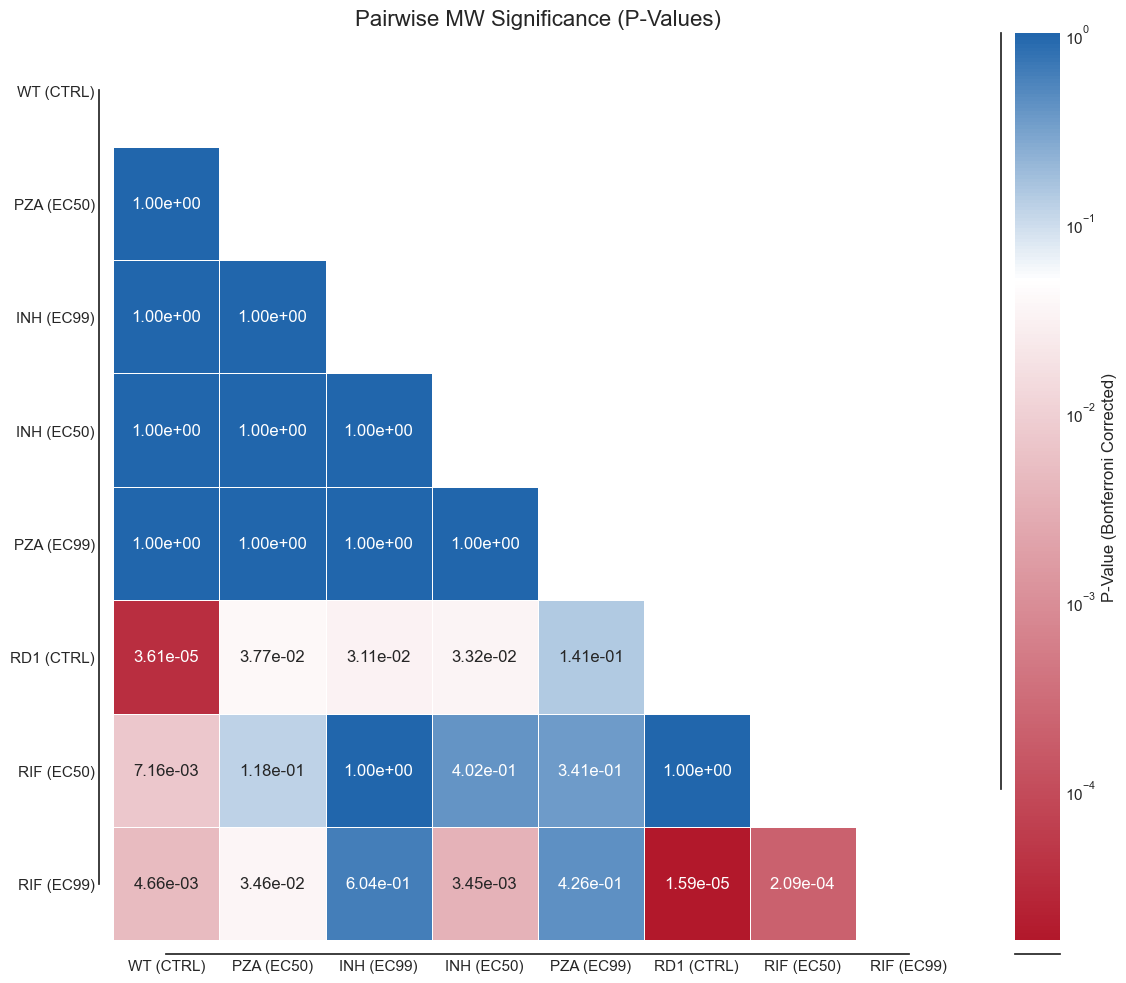

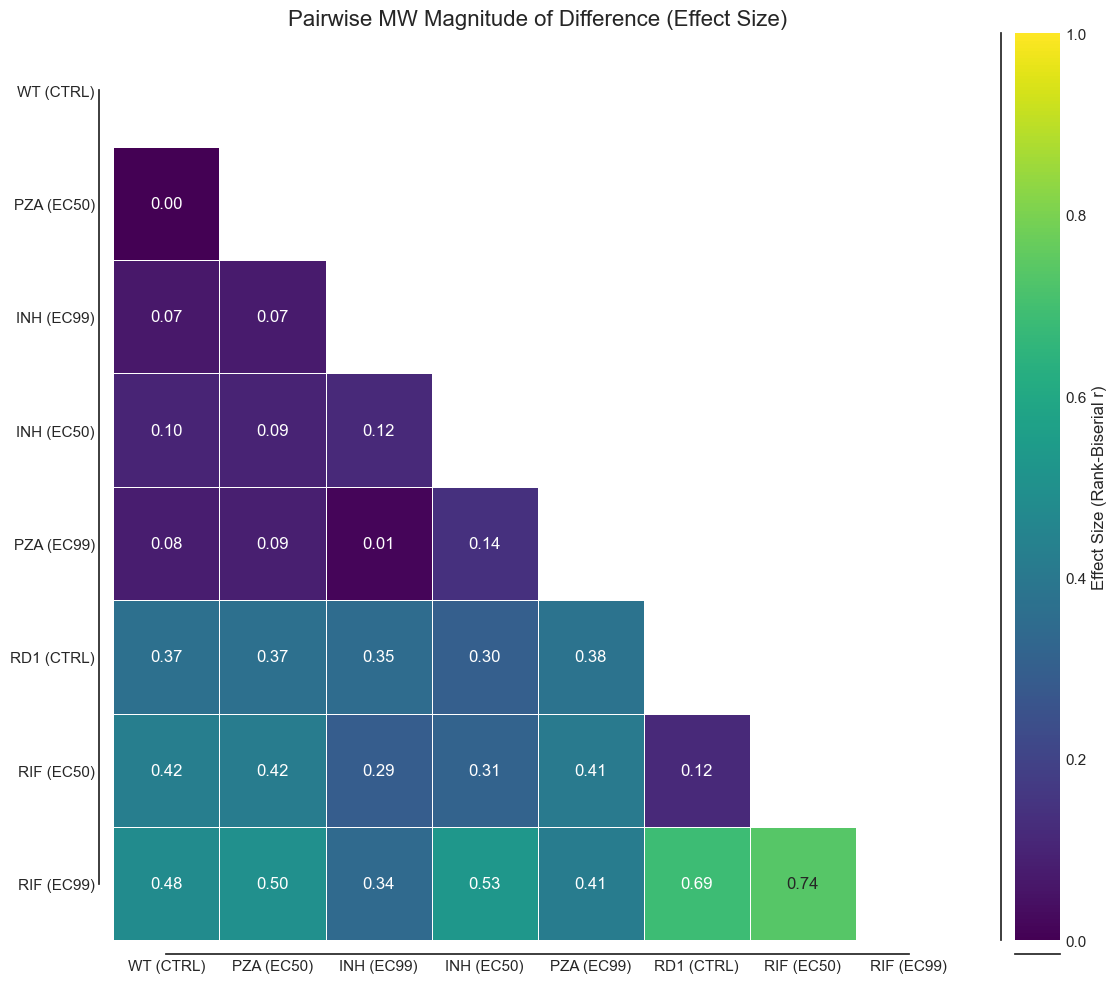

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from itertools import combinations
from matplotlib.colors import LogNorm
from statsmodels.stats.multitest import multipletests

# --- 1. Run Pairwise Tests (Mann-Whitney U) ---
# We use the raw 'df' because statistical tests need the full distribution, not just means.
groups = df['Condition'].unique()
pairs = list(combinations(groups, 2))

p_values = []
effect_sizes = [] 
group1_list = []
group2_list = []

print(f"Running pairwise comparisons for {len(pairs)} combinations...")

# 1. Force 'Doubling Times' to numeric, turning errors (strings) into NaN
df['Doubling Times'] = pd.to_numeric(df['Doubling Times'], errors='coerce')

# 2. Drop rows that became NaN or are empty
df = df.dropna(subset=['Doubling Times'])

# 3. Check if it worked (Output should say float64 or int64)
print(f"Column Type: {df['Doubling Times'].dtype}")

for g1, g2 in pairs:
    # Get the raw data for each group
    data1 = df[df['Condition'] == g1]['Doubling Times'].values
    data2 = df[df['Condition'] == g2]['Doubling Times'].values
    
    n1 = len(data1)
    n2 = len(data2)
    
    # Run Mann-Whitney U (Pairwise equivalent of Kruskal-Wallis)
    u_stat, p = stats.mannwhitneyu(data1, data2, alternative='two-sided')
    
    # Calculate Effect Size: Rank-Biserial Correlation (r)
    # This is a standard effect size for Mann-Whitney/KW. 
    # 0 = No difference, 1 = One group is completely larger than the other.
    r_rb = 1 - (2 * u_stat) / (n1 * n2)
    effect_size = abs(r_rb)
    
    p_values.append(p)
    effect_sizes.append(effect_size)
    group1_list.append(g1)
    group2_list.append(g2)

# --- 2. Apply Bonferroni Correction ---
# This adjusts P-values for the fact that we ran many tests
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

# --- 3. Build the Matrices ---
# P-Value Matrix (Default to 1.0)
p_matrix = pd.DataFrame(data=1.0, index=groups, columns=groups)
# Effect Size Matrix (Default to 0.0)
e_matrix = pd.DataFrame(data=0.0, index=groups, columns=groups)

for g1, g2, p_adj, eff in zip(group1_list, group2_list, p_adjusted, effect_sizes):
    # Fill upper triangle
    p_matrix.at[g1, g2] = p_adj
    e_matrix.at[g1, g2] = eff
    # Fill lower triangle (symmetric)
    p_matrix.at[g2, g1] = p_adj
    e_matrix.at[g2, g1] = eff

# --- 4. Plot 1: P-Values (Significance) ---
sns.set_style("white")
mask = np.triu(np.ones_like(p_matrix, dtype=bool))

# Create Custom Diverging Colormap (Red < 0.05 < Blue)
min_p_val = p_matrix[p_matrix < 1.0].min().min()
if pd.isna(min_p_val) or min_p_val >= 0.01: min_p_val = 1e-10

color_anchors = ['#b2182b', '#ffffff', '#2166ac'] # Red, White, Blue
log_min = np.log10(min_p_val)
log_center = np.log10(0.05)
center_pos = (log_center - log_min) / (0 - log_min) # 0 is log10(1.0)
center_pos = np.clip(center_pos, 0.001, 0.999)

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    'p_diverging', [(0.0, color_anchors[0]), (center_pos, color_anchors[1]), (1.0, color_anchors[2])]
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    p_matrix, mask=mask, annot=True, fmt=".2e",
    cmap=custom_cmap, norm=LogNorm(vmin=min_p_val, vmax=1.0),
    linewidths=.5, cbar_kws={'label': 'P-Value (Bonferroni Corrected)'}
)
plt.title("Pairwise MW Significance (P-Values)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

# --- 5. Plot 2: Values/Effect Size (Magnitude) ---
plt.figure(figsize=(12, 10))
sns.heatmap(
    e_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="viridis", # Sequential: Dark Blue (Low effect) -> Yellow (High effect)
    vmin=0, vmax=1, # Effect size is strictly 0 to 1
    linewidths=.5, cbar_kws={'label': 'Effect Size (Rank-Biserial r)'}
)
plt.title("Pairwise MW Magnitude of Difference (Effect Size)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

# Dunns

In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

Running Dunn's Test with Bonferroni correction...


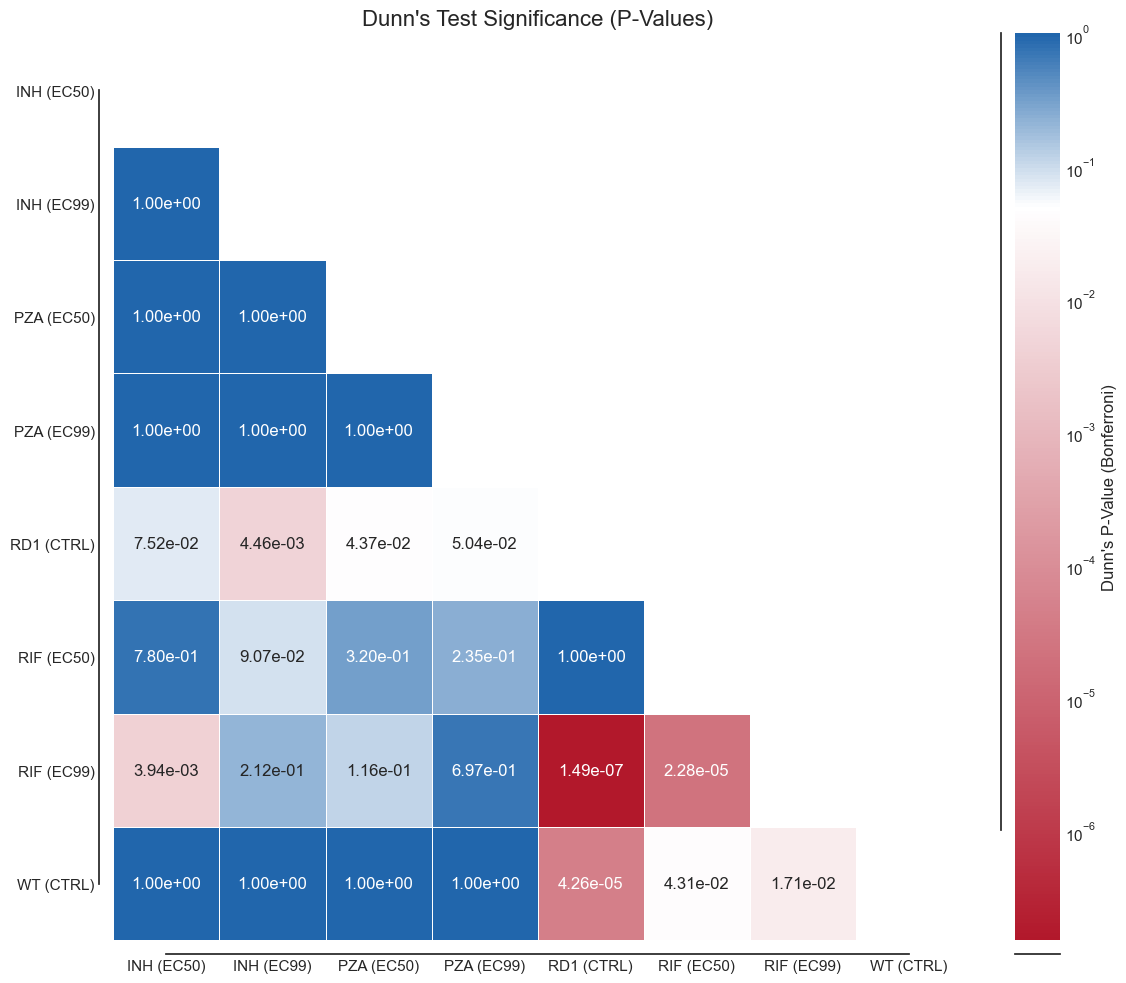

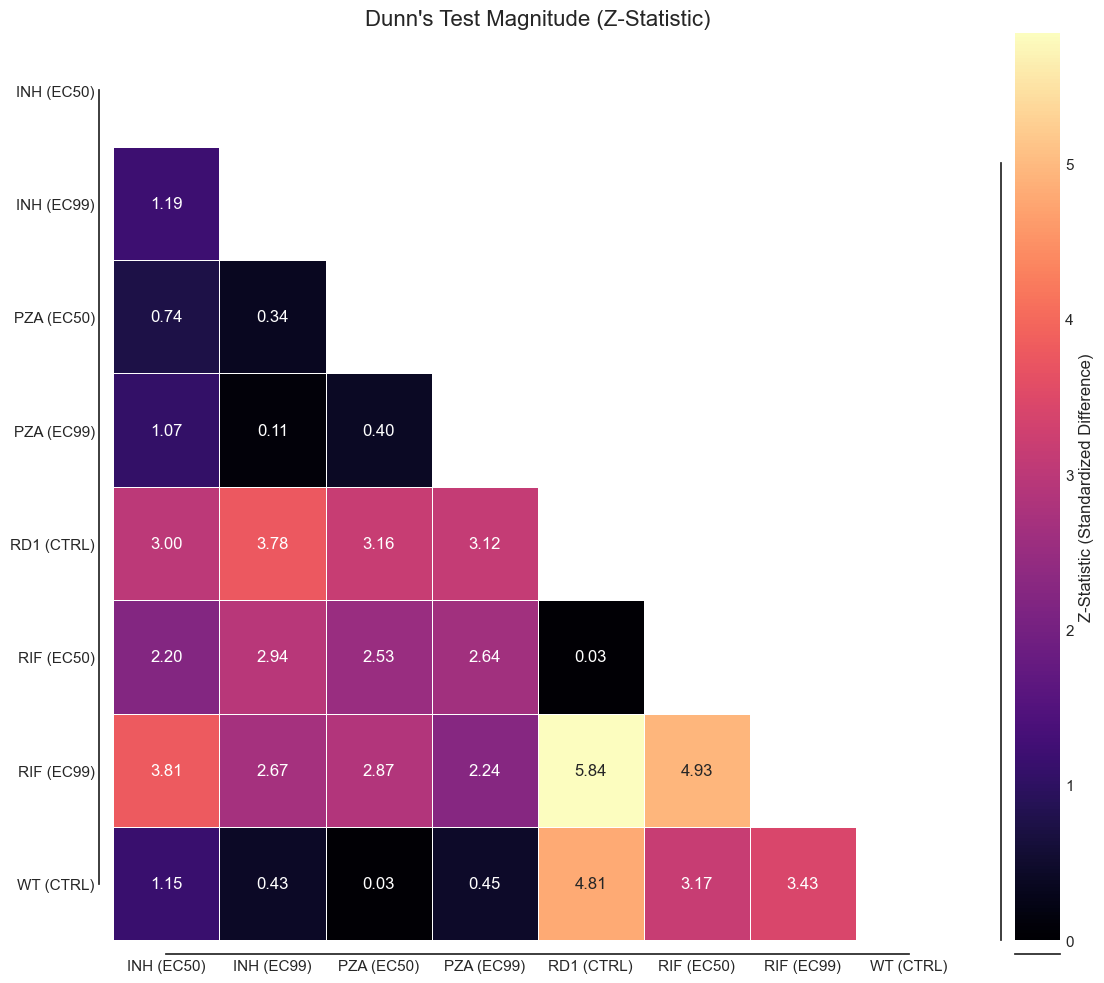

In [64]:
# --- 1. Generate P-Value Matrix (Dunn's Test) ---
print("Running Dunn's Test with Bonferroni correction...")

# This function does the heavy lifting for the P-values
p_matrix = sp.posthoc_dunn(
    df, 
    val_col='Doubling Times', 
    group_col='Condition', 
    p_adjust='bonferroni'
)

# --- 2. Calculate Z-Statistic Matrix (The "Values") ---
# Dunn's library doesn't output the Z-stats directly in a grid, so we compute them.
# Z = (Mean_Rank_A - Mean_Rank_B) / Sigma
# This tells you the standardized distance between the groups.

# Rank all data globally (Dunn's logic)
df['Global_Rank'] = df['Doubling Times'].rank()
groups = p_matrix.columns # Get group names from the p_matrix to match order
z_matrix = pd.DataFrame(index=groups, columns=groups, dtype=float)

# Pre-calculate mean rank and counts per group
stats_df = df.groupby('Condition')['Global_Rank'].agg(['mean', 'count'])
N = len(df) # Total samples

# Constant factor for Standard Error (ignoring tie correction for simplicity in visualization)
# For strict stats, ties reduce the denominator slightly, but this is sufficient for a heatmap.
base_variance = (N * (N + 1)) / 12 

for g1 in groups:
    for g2 in groups:
        if g1 == g2:
            z_matrix.at[g1, g2] = 0.0
            continue
            
        r1, n1 = stats_df.loc[g1, 'mean'], stats_df.loc[g1, 'count']
        r2, n2 = stats_df.loc[g2, 'mean'], stats_df.loc[g2, 'count']
        
        # Standard Error for this pair
        se = np.sqrt(base_variance * (1/n1 + 1/n2))
        
        # Z-score (Absolute difference / Standard Error)
        z_score = abs(r1 - r2) / se
        z_matrix.at[g1, g2] = z_score

# --- 3. Plot 1: P-Values (Significance) ---
sns.set_style("white")
mask = np.triu(np.ones_like(p_matrix, dtype=bool))

# Custom Diverging Colormap (Red < 0.05 < Blue)
min_p_val = p_matrix[p_matrix < 1.0].min().min()
if pd.isna(min_p_val) or min_p_val >= 0.01: min_p_val = 1e-10

color_anchors = ['#b2182b', '#ffffff', '#2166ac'] # Red, White, Blue
log_min = np.log10(min_p_val)
log_center = np.log10(0.05)
center_pos = (log_center - log_min) / (0 - log_min) 
center_pos = np.clip(center_pos, 0.001, 0.999)

custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    'p_diverging', [(0.0, color_anchors[0]), (center_pos, color_anchors[1]), (1.0, color_anchors[2])]
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    p_matrix, mask=mask, annot=True, fmt=".2e",
    cmap=custom_cmap, norm=LogNorm(vmin=min_p_val, vmax=1.0),
    linewidths=.5, cbar_kws={'label': 'Dunn\'s P-Value (Bonferroni)'}
)
plt.title("Dunn's Test Significance (P-Values)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

# --- 4. Plot 2: Z-Statistics (Magnitude) ---
plt.figure(figsize=(12, 10))
sns.heatmap(
    z_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="magma", # Sequential: Black/Purple (Low Z) -> Bright Orange (High Z)
    vmin=0, vmax=z_matrix.max().max(), 
    linewidths=.5, cbar_kws={'label': 'Z-Statistic (Standardized Difference)'}
)
plt.title("Dunn's Test Magnitude (Z-Statistic)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

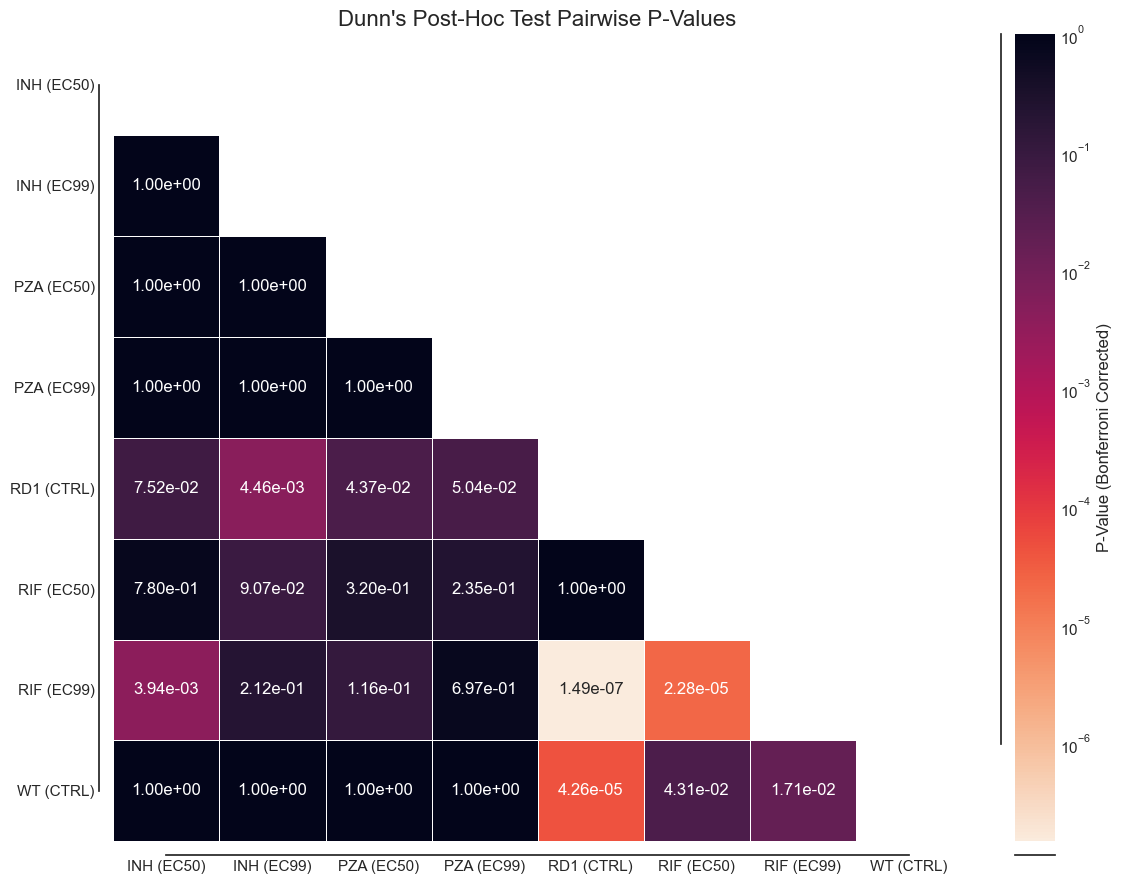

In [55]:
# --- Plotting ---
# Set the style
sns.set_style("white")

# Create a mask to hide the redundant upper triangle
# This is a standard procedure for symmetric matrices
mask = np.triu(np.ones_like(dunn_results, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(12, 9))

# Draw the heatmap
# We use a LogNorm for the color scale due to the extreme range of p-values
# A sequential colormap (like 'rocket_r') is appropriate
# Low p-values (significant) will be dark
sns.heatmap(
    dunn_results,
    mask=mask,               # Apply the mask
    annot=True,              # Show p-values in cells
    fmt=".2e",               # Format annotations in scientific notation
    cmap="rocket_r",         # Use a reversed sequential colormap
    norm=LogNorm(),          # Apply log scale to colorbar
    linewidths=.5,           # Add lines between cells
    cbar_kws={'label': 'P-Value (Bonferroni Corrected)'} # Label colorbar
)

# Add title and ensure layout is clean
plt.title("Dunn's Post-Hoc Test Pairwise P-Values", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Apply despine
sns.despine(offset=10, trim=True)

# Show the plot
plt.tight_layout()
# plt.savefig('Dunn_posthoc_pval_matrix.pdf', bbox_inches='tight', dpi=314)
plt.show()

# KS

Running KS tests for 28 pairs...
--- Pairwise KS Test (Bonferroni Corrected) ---
            WT (CTRL)  PZA (EC50)  INH (EC99)  INH (EC50)  PZA (EC99)  \
WT (CTRL)     1.00000    1.000000    0.138230         1.0         1.0   
PZA (EC50)    1.00000    1.000000    0.494036         1.0         1.0   
INH (EC99)    0.13823    0.494036    1.000000         1.0         1.0   
INH (EC50)    1.00000    1.000000    1.000000         1.0         1.0   
PZA (EC99)    1.00000    1.000000    1.000000         1.0         1.0   

            RD1 (CTRL)  RIF (EC50)  RIF (EC99)  
WT (CTRL)     0.000002    0.023247    0.001084  
PZA (EC50)    0.014278    0.099101    0.005653  
INH (EC99)    0.515032    0.218358    1.000000  
INH (EC50)    0.001244    0.370122    0.023770  
PZA (EC99)    0.155021    0.213256    1.000000  


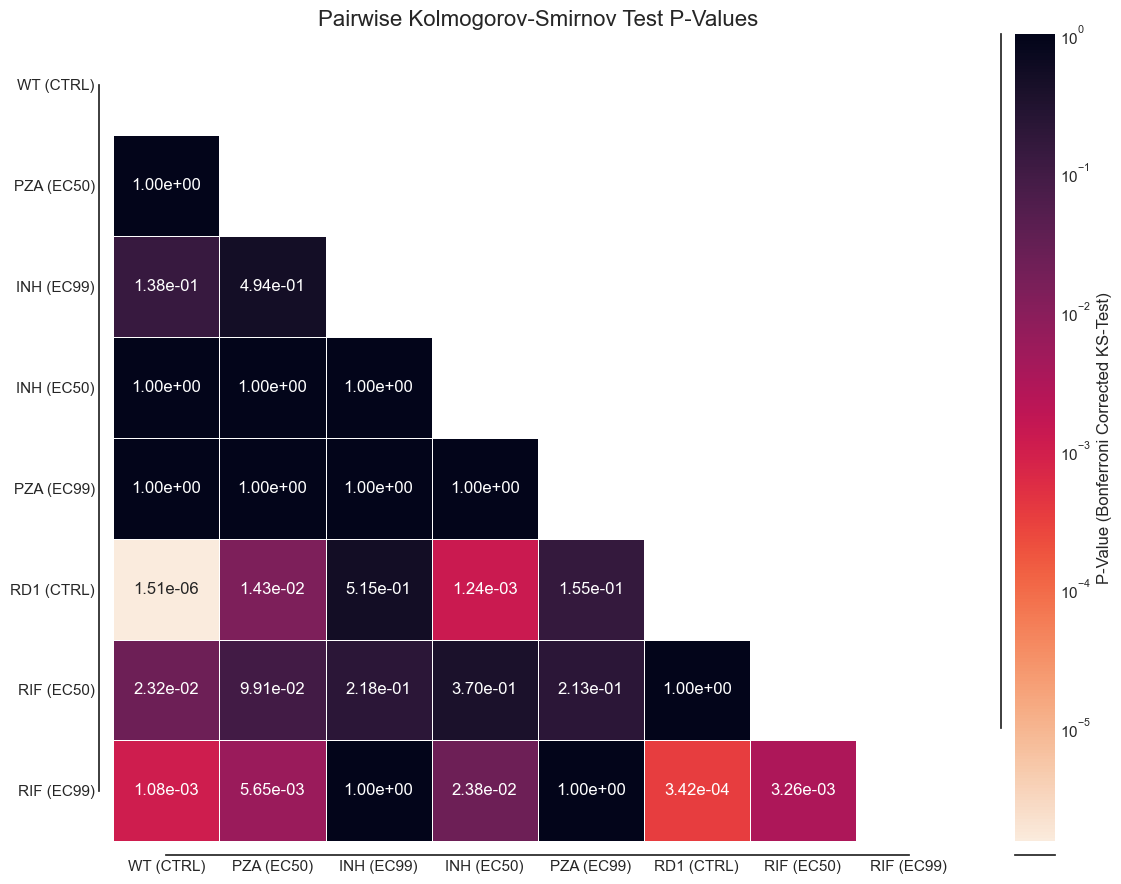

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations
from matplotlib.colors import LogNorm
from statsmodels.stats.multitest import multipletests

# --- 1. Pairwise Kolmogorov-Smirnov Tests ---

# Get unique groups
groups = df['Condition'].unique()
n_groups = len(groups)

# Generate all unique pairs of groups
pairs = list(combinations(groups, 2))

# Lists to store results
p_values = []
group1_list = []
group2_list = []

print(f"Running KS tests for {len(pairs)} pairs...")

for g1, g2 in pairs:
    # Extract data for the two groups
    data1 = df[df['Condition'] == g1]['Doubling Times'].values
    data2 = df[df['Condition'] == g2]['Doubling Times'].values
    
    # Run KS test
    # method='auto' is generally safe; exact for small N, asymp for large
    stat, p = stats.ks_2samp(data1, data2)
    
    p_values.append(p)
    group1_list.append(g1)
    group2_list.append(g2)

# --- 2. Bonferroni Correction ---

# Apply correction (Bonferroni)
# alpha=0.05 is the threshold, method='bonferroni'
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

# --- 3. Build the Matrix for Plotting ---

# Initialize a DataFrame with 1.0s (not significant)
ks_results = pd.DataFrame(data=1.0, index=groups, columns=groups)

# Fill the matrix with adjusted p-values
for g1, g2, p_adj in zip(group1_list, group2_list, p_adjusted):
    ks_results.at[g1, g2] = p_adj
    ks_results.at[g2, g1] = p_adj

print("--- Pairwise KS Test (Bonferroni Corrected) ---")
print(ks_results.head())


# --- 4. Plotting (Same as before) ---
sns.set_style("white")

# Create mask for upper triangle
mask = np.triu(np.ones_like(ks_results, dtype=bool))

plt.figure(figsize=(12, 9))

sns.heatmap(
    ks_results,
    mask=mask,
    annot=True,
    fmt=".2e",
    cmap="rocket_r",
    norm=LogNorm(),  # Log scale for p-values
    linewidths=.5,
    cbar_kws={'label': 'P-Value (Bonferroni Corrected KS-Test)'}
)

plt.title("Pairwise Kolmogorov-Smirnov Test P-Values", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

sns.despine(offset=10, trim=True)
plt.tight_layout()
# plt.savefig('KS_posthoc_pval_matrix.pdf', bbox_inches='tight', dpi=314)
plt.show()

Running KS tests for 28 pairs...
--- Pairwise KS Test (Bonferroni Corrected) ---
            WT (CTRL)  PZA (EC50)  INH (EC99)  INH (EC50)  PZA (EC99)  \
WT (CTRL)     1.00000    1.000000    0.138230         1.0         1.0   
PZA (EC50)    1.00000    1.000000    0.494036         1.0         1.0   
INH (EC99)    0.13823    0.494036    1.000000         1.0         1.0   
INH (EC50)    1.00000    1.000000    1.000000         1.0         1.0   
PZA (EC99)    1.00000    1.000000    1.000000         1.0         1.0   

            RD1 (CTRL)  RIF (EC50)  RIF (EC99)  
WT (CTRL)     0.000002    0.023247    0.001084  
PZA (EC50)    0.014278    0.099101    0.005653  
INH (EC99)    0.515032    0.218358    1.000000  
INH (EC50)    0.001244    0.370122    0.023770  
PZA (EC99)    0.155021    0.213256    1.000000  


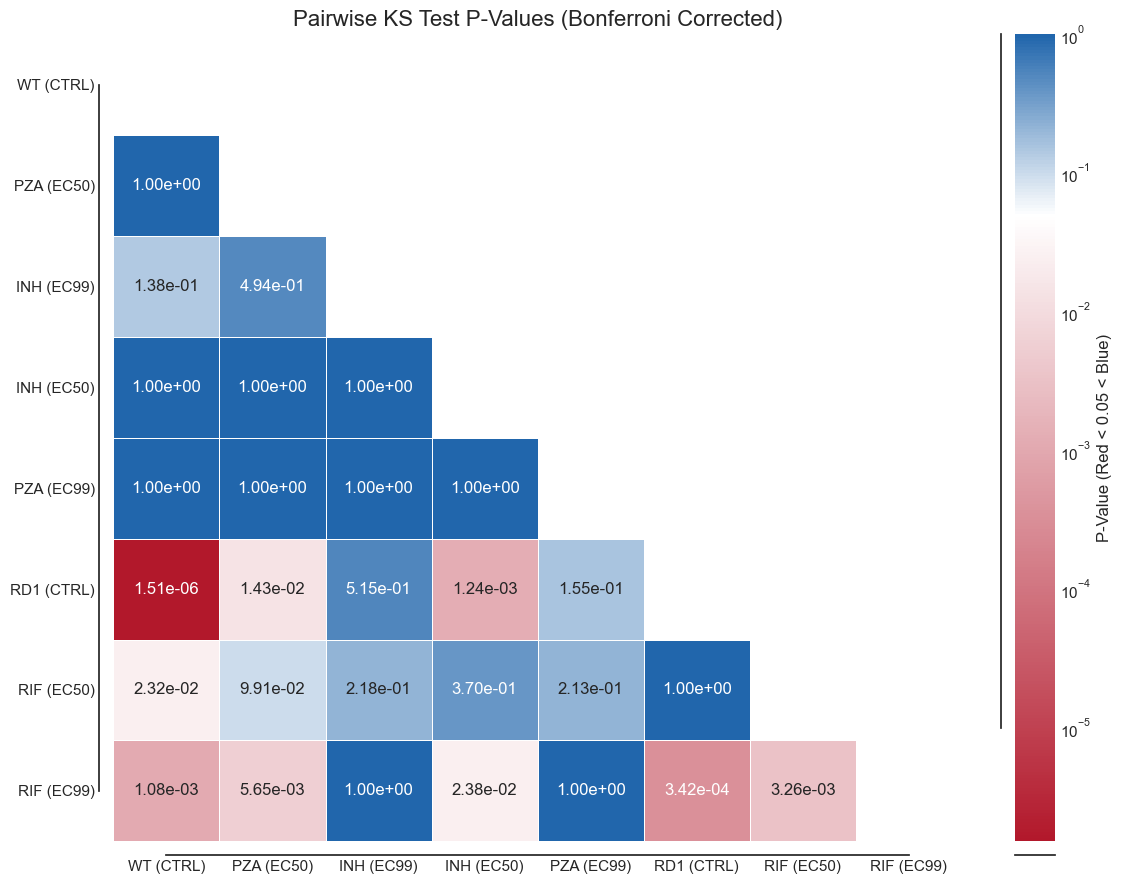

In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations
from matplotlib.colors import LogNorm
from statsmodels.stats.multitest import multipletests
import matplotlib.colors as mcolors
# --- 1. Pairwise Kolmogorov-Smirnov Tests ---

# Get unique groups
groups = df['Condition'].unique()
n_groups = len(groups)

# Generate all unique pairs of groups
pairs = list(combinations(groups, 2))

# Lists to store results
p_values = []
group1_list = []
group2_list = []

print(f"Running KS tests for {len(pairs)} pairs...")

for g1, g2 in pairs:
    # Extract data for the two groups
    data1 = df[df['Condition'] == g1]['Doubling Times'].values
    data2 = df[df['Condition'] == g2]['Doubling Times'].values
    
    # Run KS test
    # method='auto' is generally safe; exact for small N, asymp for large
    stat, p = stats.ks_2samp(data1, data2)
    
    p_values.append(p)
    group1_list.append(g1)
    group2_list.append(g2)

# --- 2. Bonferroni Correction ---

# Apply correction (Bonferroni)
# alpha=0.05 is the threshold, method='bonferroni'
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

# --- 3. Build the Matrix for Plotting ---

# Initialize a DataFrame with 1.0s (not significant)
ks_results = pd.DataFrame(data=1.0, index=groups, columns=groups)

# Fill the matrix with adjusted p-values
for g1, g2, p_adj in zip(group1_list, group2_list, p_adjusted):
    ks_results.at[g1, g2] = p_adj
    ks_results.at[g2, g1] = p_adj

print("--- Pairwise KS Test (Bonferroni Corrected) ---")
print(ks_results.head())


# --- 4. Plotting with Custom Diverging Log Colormap ---
sns.set_style("white")

# A. Setup Data and Mask
mask = np.triu(np.ones_like(ks_results, dtype=bool))
# Find the smallest non-zero p-value for the log scale lower bound
min_p_val = ks_results[ks_results > 0].min().min()
# Safety check: if min_p_val is NaN (e.g., matrix is all 0s or 1s) or too high, set a default
if pd.isna(min_p_val) or min_p_val >= 0.01: min_p_val = 1e-10

# B. Create Custom Diverging Colormap Centered at 0.05
# Define colors: [Significant (Red), Threshold (White), Not Significant (Blue)]
# Using hex codes from a standard diverging palette ('RdBu_r')
color_anchors = ['#b2182b', '#ffffff', '#2166ac']

# Calculate the logarithmic positions
log_min = np.log10(min_p_val)
log_max = np.log10(1.0)      # This is 0
log_center = np.log10(0.05)  # This is approx -1.3

# Calculate the relative position of 0.05 on a 0.0 to 1.0 scale
# Formula: (value - min) / (max - min)
center_pos = (log_center - log_min) / (log_max - log_min)

# Clip ensure the center stays within bounds if data is weird
center_pos = np.clip(center_pos, 0.001, 0.999)

# Create the colormap specifying the exact position of the center color
custom_diverging_cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_pvalue_diverging',
    [(0.0, color_anchors[0]),          # Bottom of scale (Red)
     (center_pos, color_anchors[1]),   # The 0.05 mark (White)
     (1.0, color_anchors[2])]          # Top of scale (Blue)
)

# C. Draw Plot
plt.figure(figsize=(12, 9))

sns.heatmap(
    ks_results,
    mask=mask,
    annot=True,
    fmt=".2e",
    # Use our new custom cmap
    cmap=custom_diverging_cmap,
    # Use LogNorm, ensuring vmin matches our calculation
    norm=LogNorm(vmin=min_p_val, vmax=1.0),
    linewidths=.5,
    # Update colorbar label to reflect the scheme
    cbar_kws={'label': 'P-Value (Red < 0.05 < Blue)'}
)

plt.title("Pairwise KS Test P-Values (Bonferroni Corrected)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

sns.despine(offset=10, trim=True)
plt.tight_layout()
# plt.savefig('KS_posthoc_diverging.pdf', bbox_inches='tight', dpi=314)
plt.show()

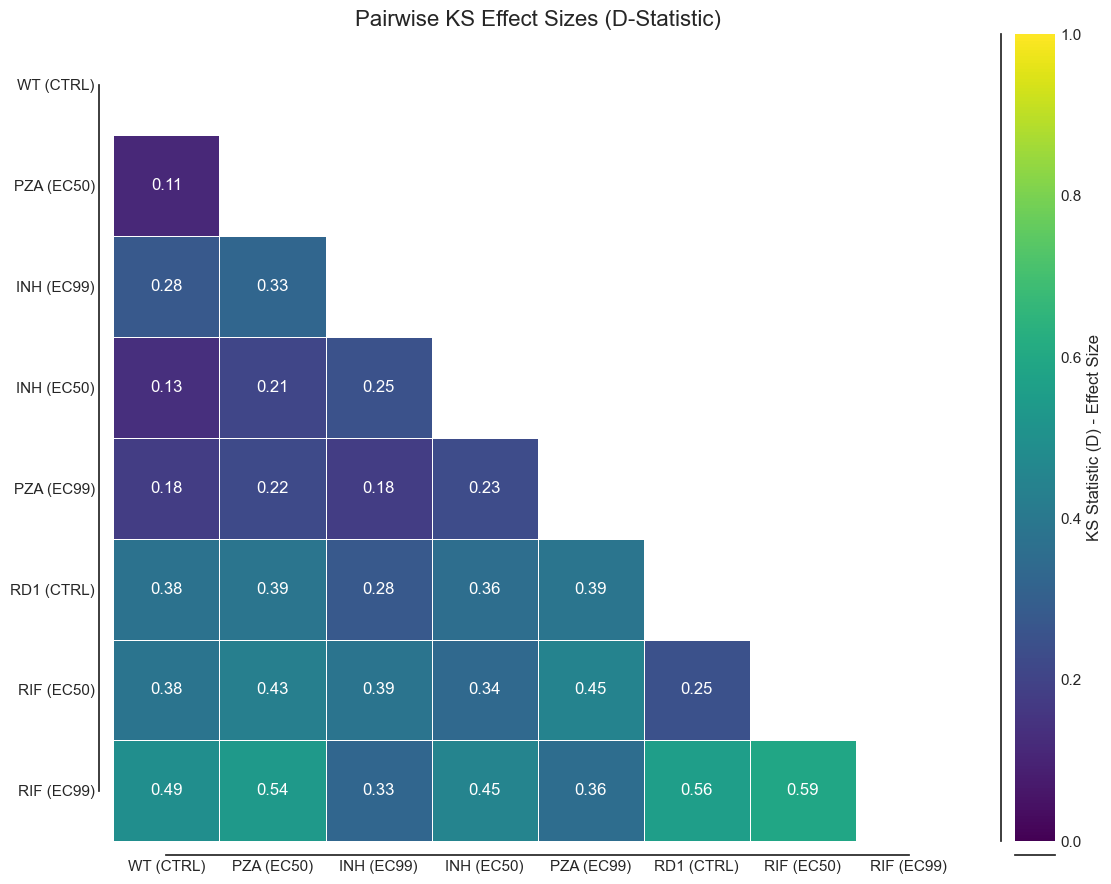

In [59]:
# --- 1. Run KS Tests and Capture D-Statistic ---
p_values = []
d_stats = []  # New list for effect sizes
group1_list = []
group2_list = []

for g1, g2 in pairs:
    data1 = df[df['Condition'] == g1]['Doubling Times'].values
    data2 = df[df['Condition'] == g2]['Doubling Times'].values
    
    # stat is the D-statistic (Effect Size)
    stat, p = stats.ks_2samp(data1, data2)
    
    p_values.append(p)
    d_stats.append(stat) # Save the D-stat
    group1_list.append(g1)
    group2_list.append(g2)

# --- 2. Build the Matrix for D-Statistics ---
# Initialize with 0.0 (since distance between a group and itself is 0)
d_matrix = pd.DataFrame(data=0.0, index=groups, columns=groups)

for g1, g2, d_val in zip(group1_list, group2_list, d_stats):
    d_matrix.at[g1, g2] = d_val
    d_matrix.at[g2, g1] = d_val

# --- 3. Plotting the Effect Size ---
sns.set_style("white")
mask = np.triu(np.ones_like(d_matrix, dtype=bool))

plt.figure(figsize=(12, 9))

sns.heatmap(
    d_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",     # 2 decimal places is usually enough for D
    cmap="viridis", # Sequential colormap: Dark = Low effect, Bright = High effect
    vmin=0, vmax=1,# D-stat is strictly bounded 0 to 1
    linewidths=.5,
    cbar_kws={'label': 'KS Statistic (D) - Effect Size'}
)

plt.title("Pairwise KS Effect Sizes (D-Statistic)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()